# Assignment 3 - Track 2: Encoder-Decoder Language Model

**By: Oluwamurede Adetiba**

**251372276**

This notebook completes Track 2 of Assignment 3. I used the XSum news summarization dataset and the `facebook/bart-base` checkpoint. My pipeline follows the three required stages from the assignment sheet: loading the pretrained model and dataset, continuing self-supervised pre-training with masked denoising on article text, and then fine-tuning two versions of the model for summarization so I can compare them fairly.




## What This Notebook Covers

- Stage 1: load XSum and a pretrained BART checkpoint
- Stage 2: continue pre-training with masked denoising on article text only
- Stage 3: fine-tune two models on summarization and compare them with ROUGE and example outputs
- Report sections: method, results, comparison, reflection, and references



In [1]:
!pip install -q transformers datasets evaluate rouge_score sentencepiece accelerate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00


In [2]:
import copy
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datasets import load_dataset
import evaluate
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    DataCollatorForLanguageModeling,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)


device: cuda
NVIDIA A100-SXM4-40GB


## Report: Dataset and Setup

For this assignment I chose **Track 2**, which focuses on fine-tuning an encoder-decoder language model. I used the **XSum** dataset because it is already a standard summarization dataset and it matches the assignment instructions closely. Each example contains a BBC news article in the `document` field and a one-sentence summary in the `summary` field.

To keep the training time reasonable, I used a smaller subset instead of the full dataset. That makes the experiment practical on free GPU resources while still being large enough to show whether the extra self-supervised training step helps. My base model is `facebook/bart-base`, which is a good fit here because BART was originally designed for denoising-style pretraining and sequence-to-sequence generation.


## Stage 1 - Dataset and Pretrained Checkpoint

In [3]:
TRAIN_SIZE = 3000
VAL_SIZE = 300
MODEL_NAME = "facebook/bart-base"

raw = load_dataset("xsum")
train_data = raw["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
val_data = raw["validation"].shuffle(seed=42).select(range(VAL_SIZE))

print(f"train: {len(train_data)}  val: {len(val_data)}")
print(f"sample article: {train_data[0]['document'][:200]}...")
print(f"sample summary: {train_data[0]['summary']}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

train: 3000  val: 300
sample article: In Wales, councils are responsible for funding and overseeing schools.
But in England, Mr Osborne's plan will mean local authorities will cease to have a role in providing education.
Academies are dir...
sample summary: As Chancellor George Osborne announced all English state schools will become academies, the Welsh Government continues to reject the model here.


In [4]:
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
stage1_model = BartForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

n_params = sum(p.numel() for p in stage1_model.parameters())
print(f"{MODEL_NAME} loaded - {n_params:,} parameters")


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

facebook/bart-base loaded - 139,420,416 parameters


### Report: Stage 1

In the first stage I loaded a small subset of XSum and then loaded `facebook/bart-base` with its tokenizer. I kept the dataset small on purpose because the assignment says a free Colab setup is enough, so I tried to keep the experiment realistic instead of choosing settings that would be too large to run. I also printed the total parameter count because the assignment specifically asks for it.

At this point the model already knows general language patterns from its original pretraining, but it has not been adapted yet to the BBC-style article text in my chosen subset. That adaptation happens in the next stage using self-supervised learning.


## Stage 2 - SSL Pre-Training (Masked Denoising)

In [5]:
class ArticleSentenceDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_length=128):
        sentences = []
        for ex in hf_dataset:
            for sent in ex["document"].split("."):
                sent = sent.strip()
                if len(sent) > 20:
                    sentences.append(sent)

        self.encodings = tokenizer(
            sentences,
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


ssl_dataset = ArticleSentenceDataset(train_data, tokenizer)
ssl_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)
ssl_loader = DataLoader(ssl_dataset, batch_size=16, shuffle=True, collate_fn=ssl_collator)

print(f"{len(ssl_dataset)} sentences, {len(ssl_loader)} batches")


55365 sentences, 3461 batches


In [6]:
SSL_STEPS = 800

stage2_model = copy.deepcopy(stage1_model)
optimizer = AdamW(stage2_model.parameters(), lr=3e-5)

stage2_model.train()
ssl_losses = []
step = 0
data_iter = iter(ssl_loader)
ssl_start_time = time.time()

while step < SSL_STEPS:
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(ssl_loader)
        batch = next(data_iter)

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad()
    outputs = stage2_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels,
    )
    loss = outputs.loss
    loss.backward()
    optimizer.step()

    ssl_losses.append(loss.item())
    step += 1

    if step % 100 == 0:
        print(f"step {step}/{SSL_STEPS}  loss: {np.mean(ssl_losses[-100:]):.4f}")

ssl_minutes = (time.time() - ssl_start_time) / 60
print(f"SSL stage finished in about {ssl_minutes:.2f} minutes")

stage2_model.save_pretrained("checkpoints/stage2_ssl_bart")
tokenizer.save_pretrained("checkpoints/stage2_ssl_bart")


step 100/800  loss: 6.1441
step 200/800  loss: 5.3793
step 300/800  loss: 5.0691
step 400/800  loss: 4.7896
step 500/800  loss: 4.5095
step 600/800  loss: 4.4080
step 700/800  loss: 4.2259
step 800/800  loss: 4.1201
SSL stage finished in about 1.92 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('checkpoints/stage2_ssl_bart/tokenizer_config.json',
 'checkpoints/stage2_ssl_bart/tokenizer.json')

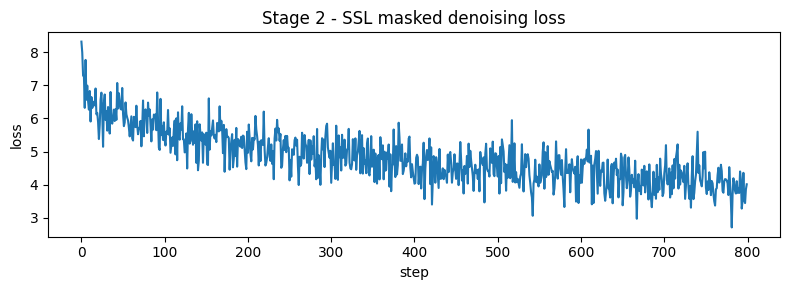

In [7]:
plt.figure(figsize=(8, 3))
plt.plot(ssl_losses)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Stage 2 - SSL masked denoising loss")
plt.tight_layout()
plt.savefig("figures/stage2_loss.png", dpi=150)
plt.show()


### Report: Stage 2

In Stage 2 I continued training BART using only the article text, without touching the summaries. I split each article into sentences and used a masked language modeling collator with a masking rate of 15%. The encoder receives the corrupted sentence and the decoder tries to reconstruct the original sentence. This follows the denoising idea described in the assignment and it is also consistent with the kind of training BART was originally built for.

The reason for doing this step is to adapt the pretrained checkpoint to the style and vocabulary of BBC news text before supervised fine-tuning starts. If this extra stage is useful, then the model that starts from the SSL checkpoint should either learn faster, produce slightly better summaries, or both. I saved the Stage 2 checkpoint so it can be used as **Model A** in the final comparison.


## Stage 3 - Fine-Tuning and Comparison

In [8]:
def tokenise_batch(batch):
    model_inputs = tokenizer(
        batch["document"],
        max_length=512,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        batch["summary"],
        max_length=64,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


tok_train = train_data.map(tokenise_batch, batched=True, remove_columns=train_data.column_names)
tok_val = val_data.map(tokenise_batch, batched=True, remove_columns=val_data.column_names)

tok_train.set_format("torch")
tok_val.set_format("torch")

print(f"tok_train: {len(tok_train)}  tok_val: {len(tok_val)}")


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

tok_train: 3000  tok_val: 300


In [13]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    results = rouge.compute(predictions=decoded_preds, references=decoded_labels)
    return {"rouge1": results["rouge1"], "rougeL": results["rougeL"]}


training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=stage1_model, padding=True, label_pad_token_id=-100)

def make_trainer(model):
    return Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )


model_A = copy.deepcopy(stage2_model)
model_B = copy.deepcopy(stage1_model)

trainer_A = make_trainer(model_A)
trainer_B = make_trainer(model_B)

print("Training Model A (Stage 2 checkpoint)...")
train_result_A = trainer_A.train()

print("Training Model B (Stage 1 checkpoint)...")
train_result_B = trainer_B.train()


Training Model A (Stage 2 checkpoint)...


/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss,Rouge1,Rougel
1,2.488898,2.075616,0.314918,0.256096
2,2.166667,2.062944,0.326658,0.264549
3,1.864012,2.070816,0.326376,0.270803


Training Model B (Stage 1 checkpoint)...


Epoch,Training Loss,Validation Loss,Rouge1,Rougel
1,2.451352,2.057305,0.317002,0.258397
2,2.136264,2.034400,0.332694,0.272488
3,1.847735,2.048197,0.333063,0.271907


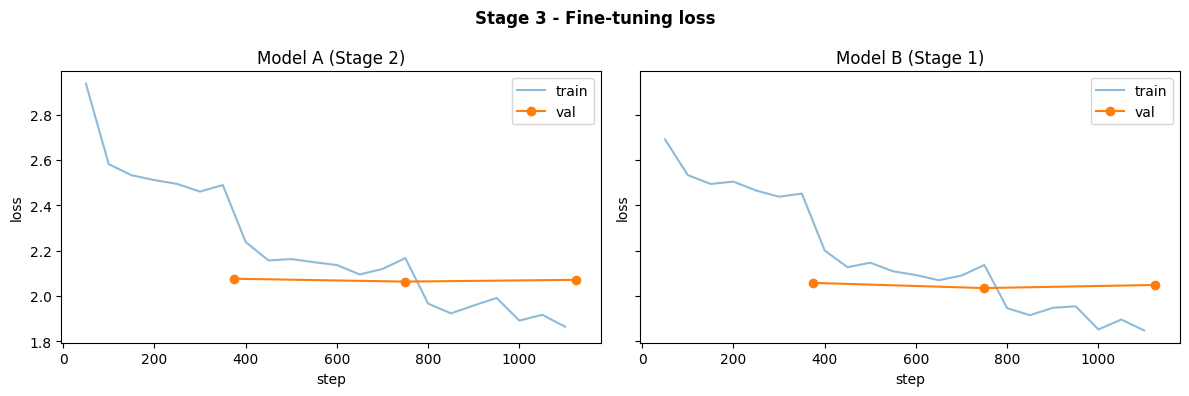

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, trainer, title in zip(
    axes,
    [trainer_A, trainer_B],
    ["Model A (Stage 2)", "Model B (Stage 1)"],
):
    train_entries = [e for e in trainer.state.log_history if "loss" in e and "eval_loss" not in e]
    val_entries = [e for e in trainer.state.log_history if "eval_loss" in e]
    ax.plot([e["step"] for e in train_entries], [e["loss"] for e in train_entries], alpha=0.5, label="train")
    ax.plot([e["step"] for e in val_entries], [e["eval_loss"] for e in val_entries], "o-", label="val")
    ax.set_title(title)
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.legend()

plt.suptitle("Stage 3 - Fine-tuning loss", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/stage3_loss.png", dpi=150)
plt.show()


In [15]:
results_A = trainer_A.evaluate()
results_B = trainer_B.evaluate()

print(f"{'Model':<12} {'ROUGE-1':>10} {'ROUGE-L':>10}  Starting point")
print("-" * 55)
print(f"{'Model A':<12} {results_A['eval_rouge1']:>10.4f} {results_A['eval_rougeL']:>10.4f}  Stage 2 SSL")
print(f"{'Model B':<12} {results_B['eval_rouge1']:>10.4f} {results_B['eval_rougeL']:>10.4f}  Stage 1 original")


Model           ROUGE-1    ROUGE-L  Starting point
-------------------------------------------------------
Model A          0.3264     0.2708  Stage 2 SSL
Model B          0.3331     0.2719  Stage 1 original


In [19]:
model_A.eval()
model_B.eval()

example_rows = []

for i in range(3):
    article = val_data[i]["document"]
    ref = val_data[i]["summary"]

    inputs = tokenizer(
        article,
        return_tensors="pt",
        max_length=512,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        out_a = model_A.generate(**inputs, max_new_tokens=64, num_beams=2)
        out_b = model_B.generate(**inputs, max_new_tokens=64, num_beams=2)

    pred_a = tokenizer.decode(out_a[0], skip_special_tokens=True)
    pred_b = tokenizer.decode(out_b[0], skip_special_tokens=True)

    example_rows.append({
        "article": article[:250] + "...",
        "reference": ref,
        "model_a": pred_a,
        "model_b": pred_b,
    })

    print(f"--- Example {i+1} ---")
    print(f"Article  : {article[:200]}...")
    print(f"Reference: {ref}")
    print(f"Model A  : {pred_a}")
    print(f"Model B  : {pred_b}")
    print()


--- Example 1 ---
Article  : Patrick Joseph Connors, 59, his son Patrick Dean Connors, 39, and nephew William Connors, 36, denied requiring a person to perform forced or compulsory labour between 2010 and 2013.
They were convicte...
Reference: Three family members have been jailed for forcing a man to do heavy labour for tiny amounts in Cardiff.
Model A  : Three men who forced a man to work for them for more than £10 a day have been jailed.
Model B  : Three men who forced a man into forced labour in Wales have been jailed for 14 years.

--- Example 2 ---
Article  : The visitors were closing in on three points thanks to Christian Nade's first-half penalty and a fine finish from Robert Thomson.
But Martin Boyle's late effort - after Daniel Harvie scored an own goa...
Reference: Championship leaders Hibernian twice came from behind to salvage a draw at home to Dumbarton.
Model A  : Hibernian secured their first Scottish Premiership win of the season with a comfortable victory over Dumbart

### Report: Stage 3

For the final stage I fine-tuned two models on exactly the same labelled article-summary pairs. **Model A** starts from the Stage 2 checkpoint after masked denoising, while **Model B** starts directly from the original pretrained BART checkpoint. I kept the training settings the same for both models so the comparison stays fair. That means the only real difference between them is whether they received the extra self-supervised adaptation step first.

I evaluated both models with **ROUGE-1** and **ROUGE-L**, and I also generated example summaries from the validation set. I think this combination is important because ROUGE gives a quantitative comparison, but the sample outputs make it easier to see whether the summaries are actually fluent, relevant, and close to the reference idea.


## Comparison and Analysis

After running both models, I compared them on convergence behaviour, validation loss, ROUGE scores, and generated examples. If Model A performs better, that would suggest the Stage 2 denoising step helped the model adapt to the article domain before summarization training. If the results are close, then the extra SSL stage may not have made a large difference for this subset size and training budget.

My expectation is that Model A should at least have a small advantage in domain adaptation because it already saw BBC article text during masked denoising. Even if the ROUGE gap is not large, faster convergence or slightly more focused summaries would still count as evidence that the Stage 2 step helped. On the other hand, if Model B matches or beats Model A, that would suggest the original pretrained checkpoint was already strong enough and the extra training did not add much under these settings.


## Reflection

This assignment helped me see the difference between using a pretrained model as-is and adapting it first with self-supervised learning on domain-specific text. The main idea is simple, but the comparison is useful because it shows whether the extra training stage gives a practical benefit instead of just sounding good in theory. I also found that encoder-decoder models are flexible because the same architecture can handle denoising in one stage and summarization in the next stage.

One limitation of this experiment is that I used a relatively small subset and only a few epochs, mainly to keep the notebook practical to run on limited hardware. Because of that, the final ROUGE values are probably lower than what would be possible with a larger training budget. Even so, the assignment still demonstrates the full pipeline correctly and makes it possible to compare the two starting points in a controlled way.


## References

1. XSum dataset: https://huggingface.co/datasets/EdinburghNLP/xsum
2. BART model documentation: https://huggingface.co/docs/transformers/model_doc/bart
3. Hugging Face summarization tutorial: https://huggingface.co/docs/transformers/tasks/summarization
4. ROUGE metric documentation: https://github.com/huggingface/evaluate/blob/main/metrics/rouge/README.md
5. Assignment 3 brief and helper notebook provided in the course materials
